
## TIMELINEDATATRAN - DADOS DE ACIDENTE DE TRANSITO, INFERENCIA

**Aluno:** Lucas Antonio Cunha Rodrigues da Silva / Marcos Beregula  
**Curso:** Ciência de Dados e IA – 3º ano   
**Disciplina:** Integração e preparação de dados  
**Professor:** Daniel dos Santos Kaster  
**Instituição:** Universidade Estadual de Londrina (UEL)    
**Data:** 26/06/2026    

# Objetivo:
**O objetivo desta atividade é ,através do datawarehouse estabelecido na primeira** 
**atividade, realizar o processo de engenharia de atributos e usando técnicas de** 
**aprendizado supervisionado prever informações de acordo com a nossa base de dados.**
**OBJETIVO:**
**"Estimar a probabilidade de um acidente resultar em óbito, dada a sua ocorrência."**

# 1. IMPORTÇÃO DAS BIBLIOTECAS

In [50]:
import pandas as pd
import psycopg2
from sklearn.utils import resample
from sqlalchemy import create_engine
from dotenv import load_dotenv
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import optuna

# 1.1 - Ajustando as configurações para visualizar todos os dados

In [6]:
# todas as colunas
pd.set_option('display.max_columns', None)

# largura da tabela
pd.set_option('display.width', None)

# Não truncar o conteúdo das células
pd.set_option('display.max_colwidth', None)

# Não quebrar DataFrames em várias "páginas"
pd.set_option('display.expand_frame_repr', False)

# 2 - CONEXAO COM BANCO DE DADOS (DATAWAREHOUSE) PRA OBTENCAO DOS DADOS:
**Criação de um dataframe com todas as informações:**

In [7]:
#NAO PRECISA RODAR JA FIZEMOS A LEITURA DO BANCO E PERSISTENCIA!!!!
conexao = psycopg2.connect(
    host="aws-1-sa-east-1.pooler.supabase.com",
    database="postgres",
    user="postgres.daaieslttburjfmsldsv",
    password="supabasekaster",
    port="5432"
)

query = """
SELECT
    f.fato_id,
    f.id_acidente,
    f.data_acidente,

    -- Métricas da fato
    f.pessoas,
    f.mortos,
    f.feridos_leves,
    f.feridos_graves,
    f.ilesos,
    f.ignorados,
    f.feridos,
    f.veiculos,
    f.fase_dia,

    -- Calendário
    c.ano,
    c.mes,
    c.dia,
    c.nome_mes,
    c.trimestre,
    c.dia_semana,
    c.nome_dia_semana,
    c.eh_fim_semana,

    -- Município
    m.nome_municipio,
    m.nome_microrregiao,
    m.nome_mesorregiao,
    m.sigla_uf,
    m.nome_uf,
    m.nome_regiao,

    -- Localização
    l.br,
    l.km,

    -- Condições da via
    v.condicao_metereologica,
    v.tipo_pista,
    v.tracado_via,
    v.sentido_via,

    -- Acidente
    a.causa_acidente,
    a.tipo_acidente,
    a.classificacao_acidente,

    -- Feriado
    fe.nome_feriado,
    fe.tipo_feriado

FROM dw.fato_acidentes_datatran f

LEFT JOIN dw.dim_calendario c
    ON f.data_acidente = c.data

LEFT JOIN dw.dim_municipios m
    ON f.id_municipio = m.id_municipio

LEFT JOIN dw.dim_localizacao l
    ON f.localizacao_id = l.localizacao_id

LEFT JOIN dw.dim_condicao_via v
    ON f.condicao_id = v.condicao_id

LEFT JOIN dw.dim_acidente a
    ON f.acidente_dim_id = a.acidente_dim_id

LEFT JOIN dw.dim_feriados fe
    ON f.id_feriado = fe.id_feriado;
"""

df = pd.read_sql_query(query, conexao)

conexao.close()

print(df.info())
print(df.head())

df.to_csv(
    "timelinedatatran.csv",
    index=False,
    encoding="utf-8-sig"
    #encoding pra evitar problemas com acentuação
)

/var/folders/54/fr9l7bd94ng5bc0gv_kvlsvh0000gn/T/ipykernel_59019/926945266.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conexao)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397415 entries, 0 to 397414
Data columns (total 37 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   fato_id                 397415 non-null  int64  
 1   id_acidente             397415 non-null  int64  
 2   data_acidente           397415 non-null  object 
 3   pessoas                 397415 non-null  int64  
 4   mortos                  397415 non-null  int64  
 5   feridos_leves           397415 non-null  int64  
 6   feridos_graves          397415 non-null  int64  
 7   ilesos                  397415 non-null  int64  
 8   ignorados               397415 non-null  int64  
 9   feridos                 397415 non-null  int64  
 10  veiculos                397415 non-null  int64  
 11  fase_dia                397415 non-null  object 
 12  ano                     397415 non-null  int64  
 13  mes                     397415 non-null  int64  
 14  dia                 

# 2.1 - Enriquecimento e tratamento no OPENREFINE:

**Realizamos a verificação da presença de clusters pra ver se havia duplicatas**
**indevidas e também algumas correções pontuais**

*Feriados de aniversarios de cidades transformados em municipais:*

*if(  
  isBlank(cells["nome_feriado"].value),  
  value,  
  if(  
    cells["nome_feriado"].value.toString().toLowercase().contains("anivers"),  
    "Municipal",  
    value  
  )  
)* 

**Excluidas 5511 observações que apresentavam condição metereológica "IGNORADO ou Ignorado"**

**Excluidas 887 observações que apresentavam SENTIDO_VIA "Não Informado"**

**INSERIDA COLUNA DUMMY PARA FERIADO**

**Alguns clusters foram encontrados:**
**Assim foi possível deixar o dataset condizente com oque buscávamos**


![clusters para causa do acidente mergeados](./clusters.jpeg)

**Imagem:** Clusters para causa do acidente mergeados no OpenRefine

# 2.2 - Abrindo o dataset LIMPO adicionando nossa coluna target, DUMMY SE MORTE 
**VAMOS PROCURAR SABER A PROPORCAO (PROBABILIDADE DE ÓBITO CONFORME DADOS DO ACIDENTE)**

In [8]:
df_clean = pd.read_csv("timelinedatatranClean.csv")
#verificando se temos valores nulos na coluna pessoas pra evitar divisão por zero
print((df_clean["pessoas"] == 0).sum())

#criando nova feature indice_fatalidade
df_clean["indice_fatalidade"] = df_clean["mortos"]/df_clean["pessoas"]
#truncando o km pra poder criar grupos mais consistentes nao precisamos da granularidade
#de centenas de metros

df_clean["km"] = np.floor(df_clean["km"]).astype(int)

#criando variavel dummy para target (ocorrencia de morte)
df_clean["target_obito"] = np.where(
    df_clean["mortos"] > 0,
    1,
    0
)
df_clean.head()

# garantir data como datetime
df_clean["data_acidente"] = pd.to_datetime(df_clean["data_acidente"])

df_clean.info()
df_clean.head()

/var/folders/54/fr9l7bd94ng5bc0gv_kvlsvh0000gn/T/ipykernel_59019/1781738290.py:1: DtypeWarning: Columns (34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("timelinedatatranClean.csv")


0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390977 entries, 0 to 390976
Data columns (total 39 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   fato_id                 390977 non-null  int64         
 1   id_acidente             390977 non-null  int64         
 2   data_acidente           390977 non-null  datetime64[ns]
 3   pessoas                 390977 non-null  int64         
 4   mortos                  390977 non-null  int64         
 5   feridos_leves           390977 non-null  int64         
 6   feridos_graves          390977 non-null  int64         
 7   ilesos                  390977 non-null  int64         
 8   feridos                 390977 non-null  int64         
 9   veiculos                390977 non-null  int64         
 10  fase_dia                390977 non-null  object        
 11  ano                     390977 non-null  int64         
 12  mes                     3909

,fato_id,id_acidente,data_acidente,pessoas,mortos,feridos_leves,feridos_graves,ilesos,feridos,veiculos,fase_dia,ano,mes,dia,nome_mes,trimestre,dia_semana,nome_dia_semana,eh_fim_semana,nome_municipio,nome_microrregiao,nome_mesorregiao,sigla_uf,nome_uf,nome_regiao,br,km,condicao_metereologica,tipo_pista,tracado_via,sentido_via,causa_acidente,tipo_acidente,classificacao_acidente,nome_feriado,tipo_feriado,feriado,indice_fatalidade,target_obito
0,10,190021,2019-02-07,3,0,1,0,2,1,3,Pleno dia,2019,2,7,Fevereiro,1,4,Quinta-feira,False,Rio Branco,Rio Branco,Vale do Acre,AC,Acre,Norte,364,111,Nublado,Simples,Reta,Crescente,Ingestão de Álcool,Colisão frontal,Com Vítimas Feridas,0,0,0,0.0,0
1,19,196789,2019-03-13,3,0,1,0,1,1,3,Pleno dia,2019,3,13,Março,1,3,Quarta-feira,False,Rio Branco,Rio Branco,Vale do Acre,AC,Acre,Norte,364,122,Nublado,Dupla,Reta,Decrescente,Falta de Atenção à Condução,Colisão traseira,Com Vítimas Feridas,0,0,0,0.0,0
2,31,105086,2018-01-21,1,0,0,0,0,0,1,Amanhecer,2018,1,21,Janeiro,1,7,Domingo,True,Rio Branco,Rio Branco,Vale do Acre,AC,Acre,Norte,364,126,Chuva,Simples,Reta,Crescente,Falta de Atenção à Condução,Saída de leito carroçável,Sem Vítimas,0,0,0,0.0,0
3,34,112918,2018-02-21,2,0,1,0,1,1,2,Plena Noite,2018,2,21,Fevereiro,1,3,Quarta-feira,False,Rio Branco,Rio Branco,Vale do Acre,AC,Acre,Norte,364,126,Céu Claro,Simples,Reta,Crescente,Falta de Atenção à Condução,Colisão traseira,Com Vítimas Feridas,0,0,0,0.0,0
4,35,146218,2018-07-12,5,0,2,0,3,2,2,Plena Noite,2018,7,12,Julho,3,4,Quinta-feira,False,Rio Branco,Rio Branco,Vale do Acre,AC,Acre,Norte,364,126,Céu Claro,Simples,Reta,Crescente,Falta de Atenção à Condução,Colisão lateral,Com Vítimas Feridas,0,0,0,0.0,0


# 2.3 - Vamos conversar com os dados?
**Nossa ideia inicial era agrupar por data local e fase do dia,**
**abaixo fica demonstrado que essa agregação pouco muda a representação do problema**

**Alguns testes apontaram que o nível de registros comparado a representação original**

**data + municipio + fase_dia = 90%**

**data + municipio = 83%**



In [9]:
# verificar se agrupando por municipio, data e fase do dia é uma boa ideia
grupos = (
    df_clean
    .groupby(["nome_municipio", "data_acidente", "fase_dia"])
    .size()
)

print(grupos.value_counts().sort_index())

#saimos de 351k linhas para 319k linhas, entao vemos que a nova representação não funciona idealmente.


#As situacão acima nao reduziu a quantidade de observacoes oque faz com que a
#agregacao por municipio, data e fase do dia nao seja uma boa ideia.
#vamos tentar outra abordagem:
#local = municipio + br + km
#momento = data + fase_dia + feriado + dia da semana
#vamos ver se essa nova representacao consegue reduzir a quantidade de observacoes
#vamos agrupar por local e momento e ver se a quantidade de observacoes é menor
grupos_3 = (
    df_clean
    .groupby(["nome_municipio", "data_acidente", ])
    .size()
)

print(grupos_3.value_counts().sort_index())

1    319392
2     26899
3      4208
4       910
5       212
6        56
7        17
8         1
Name: count, dtype: int64
1     264520
2      39790
3       9330
4       2779
5        899
6        318
7        125
8         41
9         15
10         3
Name: count, dtype: int64


# 2.4 - Definindo as variaveis a serem consideradas no modelo
**para usarmos todas as variaveis fornecidas pelo dataset resolvemos deixar as**
**colunas informativas como tipo de colisão, causa, quantidade de veículos e etc.**


In [ ]:
# colunas que vamos manter como features
features = [
    # LOCAL
    "nome_municipio",
    "sigla_uf",
    "nome_regiao",
    "br",
    "km",

    # MOMENTO
    "ano",
    "mes",
    "dia",
    "trimestre",
    "dia_semana",
    "eh_fim_semana",
    "fase_dia",

    # FERIADO
    "feriado",
    "tipo_feriado",

    # CLIMA/AMBIENTE
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "sentido_via",
    "causa_acidente",
    "tipo_acidente",
    "veiculos",
    "pessoas"
]

target = "target_obito"

df_ml = df_clean[features + [target]].copy()

display(df_ml)

,nome_municipio,sigla_uf,nome_regiao,br,km,ano,mes,dia,trimestre,dia_semana,eh_fim_semana,fase_dia,feriado,tipo_feriado,condicao_metereologica,tipo_pista,tracado_via,sentido_via,veiculos,pessoas,target_obito
0,Rio Branco,AC,Norte,364,111,2019,2,7,1,4,False,Pleno dia,0,0,Nublado,Simples,Reta,Crescente,3,3,0
1,Rio Branco,AC,Norte,364,122,2019,3,13,1,3,False,Pleno dia,0,0,Nublado,Dupla,Reta,Decrescente,3,3,0
2,Rio Branco,AC,Norte,364,126,2018,1,21,1,7,True,Amanhecer,0,0,Chuva,Simples,Reta,Crescente,1,1,0
3,Rio Branco,AC,Norte,364,126,2018,2,21,1,3,False,Plena Noite,0,0,Céu Claro,Simples,Reta,Crescente,2,2,0
4,Rio Branco,AC,Norte,364,126,2018,7,12,3,4,False,Plena Noite,0,0,Céu Claro,Simples,Reta,Crescente,2,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390972,Londrina,PR,Sul,369,158,2023,12,27,4,3,False,Plena Noite,1,Municipal,Céu Claro,Dupla,Reta,Crescente,1,2,0
390973,Paranaguá,PR,Sul,277,10,2023,12,15,4,5,False,Plena Noite,1,Municipal,Céu Claro,Dupla,Reta,Decrescente,4,4,0
390974,Soledade,RS,Sul,386,237,2023,11,10,4,5,False,Plena Noite,1,Municipal,Céu Claro,Simples,Reta,Crescente,3,4,0
390975,Palhoça,SC,Sul,101,215,2023,12,13,4,3,False,Pleno dia,1,Municipal,Céu Claro,Dupla,Reta;Interseção de Vias,Crescente,2,2,0


## 2.5 - Checando balanceamento

In [55]:
#VERIFICANDO o balanceamento da variavel target
print(df_ml["target_obito"].value_counts())

percentual_obitos = (
    df_ml["target_obito"].value_counts() / len(df_ml)
) * 100

print(percentual_obitos)

#93% dos acidentes nao resultaram em óbito

#como queremos a probabilidade vamos manter a proporcao.

#os algoritmos XGboost e LightGBM podem ser informados que a classe 1 é rara!




target_obito
0    363714
1     27263
Name: count, dtype: int64
target_obito
0    93.026956
1     6.973044
Name: count, dtype: float64


## 3 - Preparação para o modelo
**Separando features de rótulos, capturando as descritivas e criando categorias**


In [56]:
X = df_ml.drop(columns=["target_obito"])
y = df_ml["target_obito"]
print(X.shape)
print(y.shape)

#Verificando quais categorias sao descritivas (categoricas), já sabemos apenas capturando.

cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(cat_features)

#Para o LightGBM transformamos em categoria:

for col in cat_features:
    X[col] = X[col].astype("category")



(390977, 20)
(390977,)
['nome_municipio', 'sigla_uf', 'nome_regiao', 'fase_dia', 'tipo_feriado', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'sentido_via']


## Separação treino/teste
**Temos dados 6 anos, deixaremos 2023 pra teste e os demais (18,19,20,21,22) para treino**
**capturando os pesos das classes para passar pro modelo**


In [57]:
X_train = X[X["ano"] < 2023]
X_test = X[X["ano"] == 2023]

y_train = y[X["ano"] < 2023]
y_test = y[X["ano"] == 2023]

print(X_train.shape)
print(X_test.shape)

negativa = (y_train == 0).sum()
positiva = (y_train == 1).sum()

peso = negativa / positiva

print(peso)




(324223, 20)
(66754, 20)
13.415677382063937


## 4 - Declarando o modelo de aprendizado
**Escolhemos o LightGBM porque ele é um algoritmo baseado em árvores de decisão impulsionadas por Gradient Boosting,** **capaz de modelar relações complexas entre as variáveis, lidar naturalmente com atributos categóricos e numéricos e** **apresentar excelente desempenho em problemas de classificação em bases tabulares. Além disso, é eficiente computacionalmente e robusto para conjuntos de dados desbalanceados.**  


In [58]:
#testar balanceado e sem equilibrio pra ver o impacto
modelo = LGBMClassifier(

    objective="binary",

    n_estimators=300,

    learning_rate=0.05,

    num_leaves=31,

    random_state=42,

    scale_pos_weight=peso,
#testar com balanced pra ver a diferenca

    #class_weight="balanced"
)

**4.1 - treinamento, tiramos a coluna ano pois os grupos ja estao segregados por ano**

In [59]:
X_train = X_train.drop(columns=["ano"])
X_test = X_test.drop(columns=["ano"])
modelo.fit(
    X_train,
    y_train,
    categorical_feature=cat_features
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 22491, number of negative: 301732
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005397 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2303
[LightGBM] [Info] Number of data points in the train set: 324223, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.069369 -> initscore=-2.596424
[LightGBM] [Info] Start training from score -2.596424


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# 4.2 - Teste - Obtendo o vetor de probabilidades de resultar em obtito e as classes

In [60]:
probabilidades = modelo.predict_proba(X_test)[:, 1]
probabilidades_train = modelo.predict_proba(X_train)[:, 1]

#predict padrao ja usa o threshold de 0.5 pra definir a classe
#verificar se da pra melhorar isso aqui deixar mais soft


classes = modelo.predict(X_test)
classes_train = modelo.predict(X_train)

# 5 - Metricas de avaliação - CHECK DE OVERFITTING


In [61]:
#ACURACIA EM TESTE
acc_test = accuracy_score(y_train, classes_train)

#ACURACIA EM PRODUCAO
acc = accuracy_score(y_test, classes)


print(f"Acurácia em teste: {acc_test:.4f}")
print(f"Acurácia: {acc:.4f}")
print(f"A lacuna de generalização entre treino e teste é de {acc_test - acc:.4f}")

#ROC-AUC
auc = roc_auc_score(y_test, probabilidades)
auc_train = roc_auc_score(y_train, probabilidades_train)

print(f"ROC-AUC: {auc:.4f}")
print(f"ROC-AUC em treino: {auc_train:.4f}")
print(f"A lacuna de generalização via AUC entre treino e teste é de {auc_train - auc:.4f}")

#PRECISION E RECALL
print("RELATORIO DE CLASSIFICAÇÃO EM TESTE")
print(classification_report(y_test, classes))

print("RELATORIO DE CLASSIFICAÇÃO EM TREINO")
print(classification_report(y_train, classes_train))

#CONFUSION MATRIX
print("MATRIZ DE CONFUSÃO EM TESTE")
cm = confusion_matrix(y_test, classes)
print(cm)
print("MATRIZ DE CONFUSÃO EM TREINO")
cm_train = confusion_matrix(y_train, classes_train)



print(cm_train)

# recall >>> tp/(tp+fn): sensibilidade, percentual quantos positivos foram classificados corretamente

# precision >>> tp/(tp+fp): Das que dizemos serem positivas, quantas de fato são
#como a classificacao tem um gap de melhoria, fazemos uma iteracao pra observar o impacto


#PARA VISUALIZAR O IMPACTO DO LIMIAR PARA DE PROBABILIDADE PARA CLASSIFICAR COMO POSITIVO
#DESCOMENTE ABAIXO
#for t in [0.4, 0.6, 0.8]:
#    y_pred = (probabilidades >= t).astype(int)

    #print(f"\nLimiar = {t}")
    #print(classification_report(y_test, y_pred))

#dobramos os acertos em positivos
    


Acurácia em teste: 0.7557
Acurácia: 0.7152
A lacuna de generalização entre treino e teste é de 0.0405
ROC-AUC: 0.7458
ROC-AUC em treino: 0.8749
A lacuna de generalização via AUC entre treino e teste é de 0.1291
RELATORIO DE CLASSIFICAÇÃO EM TESTE
              precision    recall  f1-score   support

           0       0.96      0.72      0.82     61982
           1       0.15      0.65      0.25      4772

    accuracy                           0.72     66754
   macro avg       0.56      0.69      0.54     66754
weighted avg       0.91      0.72      0.78     66754

RELATORIO DE CLASSIFICAÇÃO EM TREINO
              precision    recall  f1-score   support

           0       0.98      0.75      0.85    301732
           1       0.20      0.84      0.32     22491

    accuracy                           0.76    324223
   macro avg       0.59      0.79      0.59    324223
weighted avg       0.93      0.76      0.81    324223

MATRIZ DE CONFUSÃO EM TESTE
[[44637 17345]
 [ 1667  3105]]
MAT

# 5.1 - Análise dos resultados:
**O modelo não está ruim, ele perde 0.04 de acurácia entre treino e teste, porém**
**precisamos pensar que a acurácia para nosso modelo não é a métrica que nos interessa**
**dado o problema que queremos resolver (probabilidades). Ja na AUC, o modelo perde 1,1%**
**Existem alterações mais consideráveis quando paramos para analisar recall e F1 também**
**o que também não é alarmante, talvez pra análise de fraudes não seja ideal mas para nossa**
**proposta seria aceitável. Mas vamos buscar melhorar o resultado através da sintonia dos parâmetros**


Conclusão: Modelo saudável, overfitting moderado (11 pontos na AUC) - aprendeu alguns padrões.




# 5.2 - PENSAMENTO ADICIONAL: BALANCEAR MELHORA A CLASSIFICACAO??? 

In [53]:
#capturamos as classes
df_classe0 = df_ml[df_ml["target_obito"] == 0]
df_classe1 = df_ml[df_ml["target_obito"] == 1]
df_classe0_balanceada = resample(
    df_classe0,
    replace=False,
    n_samples=len(df_classe1),
    random_state=42
)

#junta pra criar o novo dataframe balanceado
df_balanceado = pd.concat(
    [df_classe0_balanceada, df_classe1],
    axis=0
)

#aleatoriza/mistura o dataframe

df_balanceado = df_balanceado.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)


X_balanced = df_balanceado.drop(columns=["target_obito"])
y_balanced = df_balanceado["target_obito"]


cat_features_balanced = X_balanced.select_dtypes(
    include=["object", "category"]
).columns.tolist()

for col in cat_features_balanced:
    X_balanced[col] = X_balanced[col].astype("category")

print(X_balanced.shape)
print(y_balanced.value_counts())

X_balanced_train = X_balanced[X_balanced["ano"] < 2023]
X_balanced_test = X_balanced[X_balanced["ano"] == 2023]

y_balanced_train = y_balanced[X_balanced["ano"] < 2023]
y_balanced_test = y_balanced[X_balanced["ano"] == 2023]

modelo_balanceado = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    class_weight="balanced"
)

X_balanced_train = X_balanced_train.drop(columns=["ano"])
X_balanced_test = X_balanced_test.drop(columns=["ano"])

modelo_balanceado.fit(
    X_balanced_train,
    y_balanced_train,
    categorical_feature=cat_features_balanced
)


probabilidades_balanceadas = modelo_balanceado.predict_proba(X_balanced_test)[:, 1]

classes_balanceadas = modelo_balanceado.predict(X_balanced_test)

acc_balanceado = accuracy_score(y_balanced_test, classes_balanceadas)

print(f"============METRICAS BALANCEADAS============")

print(f"Acurácia balanceada: {acc_balanceado:.4f}")

roc_auc_balanceado = roc_auc_score(y_balanced_test, probabilidades_balanceadas)

print(f"ROC-AUC balanceado: {roc_auc_balanceado:.4f}")

recall_balanceado = recall_score(y_balanced_test, classes_balanceadas)

print(f"Recall balanceado: {recall_balanceado:.4f}")

f1_balanceado = f1_score(y_balanced_test, classes_balanceadas)

print(f"F1 balanceado: {f1_balanceado:.4f}")



(40700, 22)
target_obito
0    20350
1    20350
Name: count, dtype: int64
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 16881, number of negative: 17008
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001040 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2162
[LightGBM] [Info] Number of data points in the train set: 33889, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
============METRICAS BALANCEADAS============
Acurácia balanceada: 0.7397
ROC-AUC balanceado: 0.8245
Recall balanceado: 0.7561
F1 balanceado:

# 5.3 - Insight revelado:

**Notamos que o desempenho do modelo não melhorou expressivamente, pois AUC muda pouco**
**as métricas que se mostraram superiores foram 'puxadas' devido a classe 1 ser mais**
**representativa agora, o que impacta na diminuição da acurácia e aumento de precision e recall**

**Contextualizando:**

**RECALL: TP/(TP+FN) >>> REVOKE/SENSITIVITY: PERCENTUAL DE POSITIVOS CLASSIFICADOS CORRETAMENTE**
**PRECISION: TP/(TP+FP) >>>TRUE POSITIVE RATIO DOS POSITIVOS PREVISTOS QUANTOS SAO REALMENTE POSITIVOS?**


## 6- MOSTRANDO AS 20 MAIORES PROBABILIDADES DE ÓBITOS PARA ACIDENTES, AREAS MAIS PERIGOSAS

In [19]:
resultado = X_test.copy()

resultado["Probabilidade_Obito"] = probabilidades

resultado["Real"] = y_test.values

resultado = resultado.sort_values(
    "Probabilidade_Obito",
    ascending=False
)

resultado.head(20)

,nome_municipio,sigla_uf,nome_regiao,br,km,mes,dia,trimestre,dia_semana,eh_fim_semana,fase_dia,feriado,tipo_feriado,condicao_metereologica,tipo_pista,tracado_via,sentido_via,causa_acidente,tipo_acidente,veiculos,pessoas,Probabilidade_Obito,Real
161468,Várzea Alegre,CE,Nordeste,230,81,2,19,1,7,True,Plena Noite,0,0,Céu Claro,Simples,Reta,Crescente,Acessar a via sem observar a presença dos outros veículos,Atropelamento,2,2,0.980824,0
388988,Araripina,PE,Nordeste,316,17,12,15,4,5,False,Plena Noite,1,Municipal,Céu Claro,Simples,Aclive;Reta,Crescente,Transitar em local proibido,Colisão frontal,2,37,0.980604,0
60574,Várzea Alegre,CE,Nordeste,230,77,11,28,4,2,False,Plena Noite,0,0,Céu Claro,Simples,Reta;Aclive,Decrescente,Transitar em local proibido,Colisão frontal,2,2,0.980382,1
171384,Gaspar,SC,Sul,470,45,8,4,3,5,False,Amanhecer,0,0,Céu Claro,Simples,Curva;Em Obras,Crescente,Transitar em local proibido,Colisão frontal,3,13,0.977925,1
201393,Bacabal,MA,Nordeste,316,368,8,5,3,6,True,Plena Noite,1,Municipal,Céu Claro,Simples,Reta,Decrescente,Transitar em local proibido,Colisão frontal,4,4,0.977453,0
167015,Uruaçu,GO,Centro-Oeste,153,205,7,3,3,1,False,Amanhecer,0,0,Céu Claro,Simples,Aclive,Crescente,Transitar em local proibido,Colisão frontal,6,52,0.977025,1
292160,Aparecida,SP,Sudeste,116,75,12,4,4,1,False,Amanhecer,1,Municipal,Céu Claro,Dupla,Reta,Crescente,pedestre na via,Atropelamento,5,5,0.976486,1
350208,Várzea Alegre,CE,Nordeste,230,83,10,20,4,5,False,Amanhecer,0,0,Céu Claro,Simples,Reta,Crescente,Transitar em local proibido,Colisão frontal,2,2,0.975840,1
70874,São José dos Pinhais,PR,Sul,116,97,4,16,2,7,True,Amanhecer,0,0,Chuva,Dupla,Reta,Decrescente,pedestre na via,Atropelamento,4,5,0.975665,1
200340,Lagoa Grande,MG,Sudeste,40,98,2,11,1,6,True,Amanhecer,1,Municipal,Céu Claro,Simples,Reta,Crescente,Transitar em local proibido,Colisão frontal,4,22,0.974798,1


# 7 - ANALISE DE OUTLIERS NUMERICOS
**definindo as numericas e conhecendo a distribuicao através de histogramas**


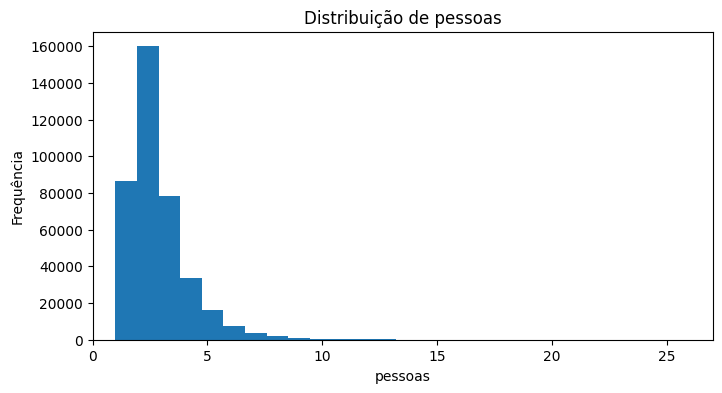

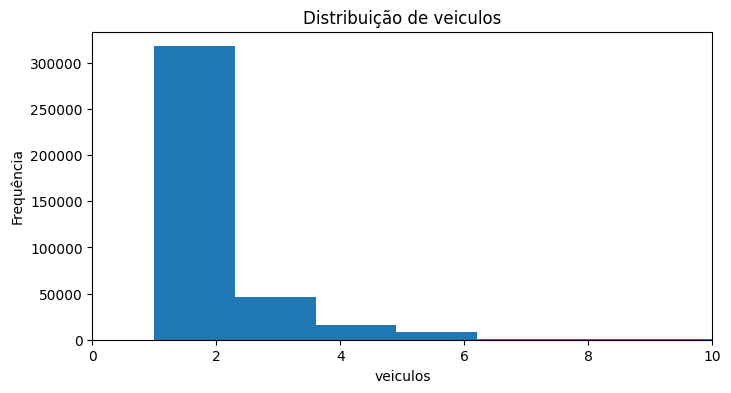

In [20]:
colunas_outliers = ["pessoas", "veiculos"]

for col in colunas_outliers:

    limite = df_ml[col].quantile(0.999)
    plt.figure(figsize=(8, 4))
    plt.hist(df_ml[col].dropna(), bins=100)
    plt.title(f"Distribuição de {col}")
    plt.xlim(0, limite)
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.show()

# 7.1 - **Dispersão e boxplot**

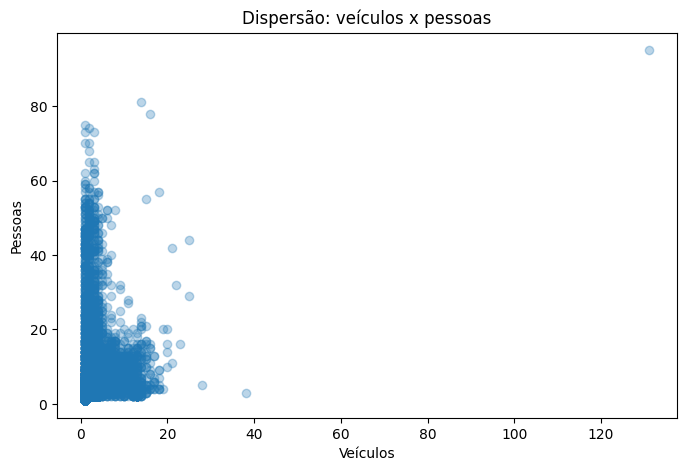

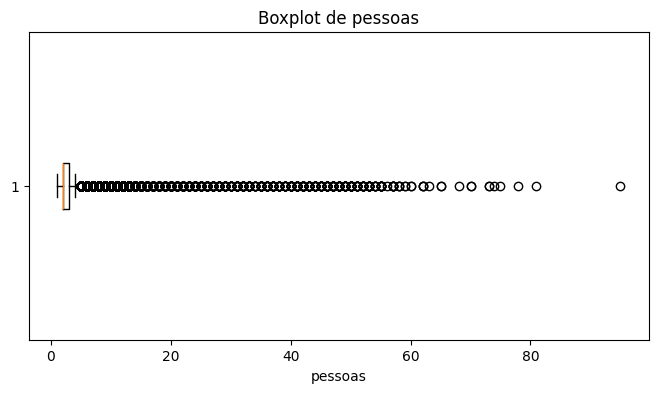

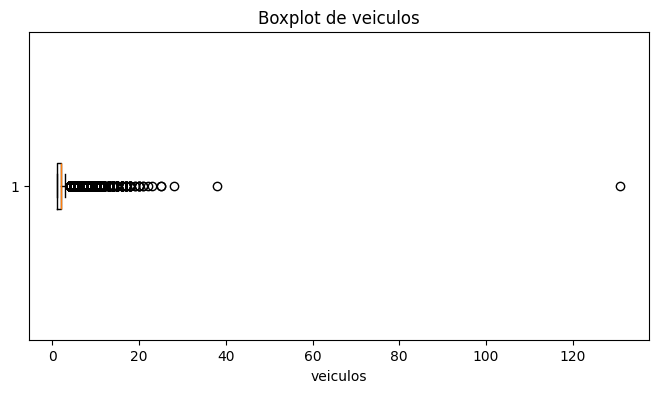

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(df_ml["veiculos"], df_ml["pessoas"], alpha=0.3)
plt.title("Dispersão: veículos x pessoas")
plt.xlabel("Veículos")
plt.ylabel("Pessoas")
plt.show()

for col in colunas_outliers:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df_ml[col].dropna(), vert=False)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

# 7.2 - Interquartil para outliers
**Metrica robusta, nao puxada pela média e aplicando regra de TUKEY para os limites**

In [22]:
def detectar_outliers_iqr(df, coluna):
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

#limites nao sao fixos dependem da dispersao dos dados

    outliers = df[
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ]

    return limite_inferior, limite_superior, outliers
    
#aplicando a funcao para cada coluna

for col in colunas_outliers:
    li, ls, outs = detectar_outliers_iqr(df_ml, col)
    print(f"\nColuna: {col}")
    print(f"Limite inferior: {li}")
    print(f"Limite superior: {ls}")
    print(f"Qtd outliers: {len(outs)}")
    print(f"Percentual: {len(outs) / len(df_ml) * 100:.2f}%")


Coluna: pessoas
Limite inferior: 0.5
Limite superior: 4.5
Qtd outliers: 32471
Percentual: 8.31%

Coluna: veiculos
Limite inferior: -0.5
Limite superior: 3.5
Qtd outliers: 27028
Percentual: 6.91%


# 7.4 - REMOÇÃO DOS OUTLIERS PARA EFEITO DE TESTE
**Apesar do modelo selecionado trabalhar bem com valores extremos, realizamos a remoção**
**para verificar o impacto nas métricas**

In [23]:
#verificando e removendo outliers de acordo com o IQR
for col in colunas_outliers:
    li, ls, _ = detectar_outliers_iqr(df_ml, col)
    df_ml = df_ml[(df_ml[col] >= li) & (df_ml[col] <= ls)]

# Verificando novamente o balanceamento
print(df_ml["target_obito"].value_counts())

# novo split
X2 = df_ml.drop(columns=["target_obito"])
y2 = df_ml["target_obito"]

#Salvando como categoria
cat_features = X2.select_dtypes(include=["object", "category"]).columns.tolist()

for col in cat_features:
    X2[col] = X2[col].astype("category")


#teste com separacao por ano sem outliers o resultado foi o mesmo
#X_train2 = X2[X2["ano"] < 2023]
#X_test2 = X2[X2["ano"] == 2023]

#y_train2 = y2[X2["ano"] < 2023]
#y_test2 = y2[X2["ano"] == 2023]

#experimentando com separacao por estratificacao mantendo a proporcao das classes:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42,
    stratify=y2
)
#notamos que o resultado foi similar, leve melhora.

 #treinando o modelo com os dados sem outliers
modelo2 = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    class_weight="balanced"
)
#dropando o ano pois os grupos ja estao segregados por ano
X_train2 = X_train2.drop(columns=["ano"])
X_test2 = X_test2.drop(columns=["ano"])
modelo2.fit(
    X_train2,
    y_train2,
    categorical_feature=cat_features
)

target_obito
0    321872
1     20350
Name: count, dtype: int64
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 16280, number of negative: 257497
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004889 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2324
[LightGBM] [Info] Number of data points in the train set: 273777, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# 7.5 TESTE sem outliers

In [28]:
y2_prob = modelo2.predict_proba(X_test2)[:, 1]
y2_pred = modelo2.predict(X_test2)

y2_pred_train = modelo2.predict(X_train2)
#Métricas de avaliação
acc2 = accuracy_score(y_test2, y2_pred)

acc2_test = accuracy_score(y_train2, y2_pred_train)
auc2 = roc_auc_score(y_test2, y2_prob)
print(f"Acurácia em teste: {acc2_test:.4f}")
print(f"Acurácia: {acc2:.4f}")
print(f"ROC-AUC: {auc2:.4f}")

print(classification_report(y_test2, y2_pred))

#Matriz de confusão
cm2 = confusion_matrix(y_test2, y2_pred)

print(f"O erro empírico treino e teste é de {acc2_test - acc2:.4f}")

Acurácia em teste: 0.8582
Acurácia: 0.8286
ROC-AUC: 0.8172
              precision    recall  f1-score   support

           0       0.97      0.84      0.90     64375
           1       0.20      0.63      0.30      4070

    accuracy                           0.83     68445
   macro avg       0.59      0.73      0.60     68445
weighted avg       0.93      0.83      0.87     68445

O erro empírico treino e teste é de 0.0296


# 8 - Otimização do modelo

Otimização dos hiperparâmetros do LightGBM com **Optuna** e escolha do melhor limiar de decisão.

Utiliza `X2`, `y2` e `cat_features` (seção 7.4) sem alterá-los, criando variáveis novas para evitar conflitos.

In [80]:

# 8 - Otimização do modelo LightGBM com Optuna

# Silencia logs verbosos do Optuna (opcional)
optuna.logging.set_verbosity(optuna.logging.WARNING)



# Separação dos dados (60% treino / 20% validação / 20% holdout)
# Usamos cópias para não alterar X2 e y2

X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X2.copy(),
    y2.copy(),
    test_size=0.20,
    stratify=y2,
    random_state=42,
)

X_train_opt, X_valid_opt, y_train_opt, y_valid_opt = train_test_split(
    X_dev.copy(),
    y_dev.copy(),
    test_size=0.25,  # 25% de X_dev -> ~20% do total = validação
    stratify=y_dev,
    random_state=42,
)

# Mesmo critério do modelo2: ano não entra no treino
for df_opt in [X_train_opt, X_valid_opt, X_dev, X_holdout]:
    if "ano" in df_opt.columns:
        df_opt.drop(columns=["ano"], inplace=True)

print(f"Treino:      {X_train_opt.shape[0]:,} amostras")
print(f"Validação:   {X_valid_opt.shape[0]:,} amostras")
print(f"Desenvolvimento (treino+val): {X_dev.shape[0]:,} amostras")
print(f"Holdout (teste): {X_holdout.shape[0]:,} amostras")


#Colunas categóricas
# Converte apenas colunas de cat_features que existirem em cada dataframe

def aplicar_categorias(lista_dfs, lista_cat):
    """Converte colunas categóricas existentes para dtype category."""
    for df_temp in lista_dfs:
        for col in lista_cat:
            if col in df_temp.columns:
                df_temp[col] = df_temp[col].astype("category")


aplicar_categorias(
    [X_train_opt, X_valid_opt, X_dev, X_holdout],
    cat_features,
)

# Lista de categóricas efetivamente usadas no treino (após remover ano)
cat_features_opt = [col for col in cat_features if col in X_train_opt.columns]
print(f"Categóricas usadas na otimização: {cat_features_opt}")



# Optuna: maximizar ROC-AUC na validação

def objective(trial):
    """Função objetivo do Optuna: treina no treino e avalia ROC-AUC na validação."""

    params = {
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.10),
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "subsample": trial.suggest_float("subsample", 0.70, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.70, 1.00),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
    }

    modelo_trial = LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        random_state=42,
        **params,
    )

    modelo_trial.fit(
        X_train_opt,
        y_train_opt,
        categorical_feature=cat_features_opt,
    )

    prob_valid = modelo_trial.predict_proba(X_valid_opt)[:, 1]
    return roc_auc_score(y_valid_opt, prob_valid)


# Executa a busca (30 tentativas)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

melhores_params = study.best_params
melhor_roc_auc_valid = study.best_value

print("\n=== Resultado do Optuna ===")
print("Melhores hiperparâmetros:", melhores_params)
print(f"Melhor ROC-AUC na validação: {melhor_roc_auc_valid:.4f}")


# Treinamento do modelo final com treino + validação (X_dev)

modelo_otimizado = LGBMClassifier(
    objective="binary",
    class_weight="balanced",
    random_state=42,
    **melhores_params,
)

modelo_otimizado.fit(
    X_dev,
    y_dev,
    categorical_feature=cat_features_opt,
)



# ETAPA 5 - Escolha do melhor limiar de decisão (maior F1 da classe positiva)
# Avaliação feita em X_dev (desenvolvimento completo) = treino + validação

prob_dev = modelo_otimizado.predict_proba(X_dev)[:, 1]
limiares = np.arange(0.20, 0.85, 0.05)  # 0.20, 0.25, ..., 0.80

resultados_limiar = []

for limiar in limiares:
    y_pred_dev = (prob_dev >= limiar).astype(int)

    resultados_limiar.append(
        {
            "limiar": limiar,
            "accuracy": accuracy_score(y_dev, y_pred_dev),
            "precision": precision_score(y_dev, y_pred_dev, zero_division=0),
            "recall": recall_score(y_dev, y_pred_dev, zero_division=0),
            "f1": f1_score(y_dev, y_pred_dev, zero_division=0),
        }
    )

df_limiares = pd.DataFrame(resultados_limiar)
melhor_limiar = float(df_limiares.loc[df_limiares["f1"].idxmax(), "limiar"])
melhor_f1_dev = float(df_limiares["f1"].max())

print("\n=== Escolha do limiar ===")
print(f"Melhor limiar: {melhor_limiar:.2f}")
print(f"F1 correspondente (desenvolvimento): {melhor_f1_dev:.4f}")
display(df_limiares)



# Avaliação final em desenvolvimento e holdout

def calcular_metricas(y_real, y_prob, limiar):
    """Calcula métricas para um conjunto usando probabilidades e um limiar."""
    y_pred = (y_prob >= limiar).astype(int)

    return {
        "accuracy": accuracy_score(y_real, y_pred),
        "roc_auc": roc_auc_score(y_real, y_prob),
        "precision_pos": precision_score(y_real, y_pred, zero_division=0),
        "recall_pos": recall_score(y_real, y_pred, zero_division=0),
        "f1_pos": f1_score(y_real, y_pred, zero_division=0),
        "y_pred": y_pred,
    }


def avaliar_e_imprimir(nome_conjunto, X_conjunto, y_conjunto):
    """Avalia modelo_otimizado + melhor_limiar e imprime relatório completo."""
    prob = modelo_otimizado.predict_proba(X_conjunto)[:, 1]
    metricas = calcular_metricas(y_conjunto, prob, melhor_limiar)

    print(f"\n{'=' * 60}")
    print(f"AVALIAÇÃO - {nome_conjunto}")
    print(f"{'=' * 60}")
    print(f"Accuracy:  {metricas['accuracy']:.4f}")
    print(f"ROC-AUC:   {metricas['roc_auc']:.4f}")
    print(f"Precision (classe 1): {metricas['precision_pos']:.4f}")
    print(f"Recall (classe 1):    {metricas['recall_pos']:.4f}")
    print(f"F1 (classe 1):        {metricas['f1_pos']:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_conjunto, metricas["y_pred"], zero_division=0))

    print("Matriz de Confusão:")
    print(confusion_matrix(y_conjunto, metricas["y_pred"]))

    return metricas


metricas_dev = avaliar_e_imprimir("DESENVOLVIMENTO (treino + validação)", X_dev, y_dev)
metricas_holdout = avaliar_e_imprimir("TESTE (holdout)", X_holdout, y_holdout)



# Análise de generalização (gaps entre desenvolvimento e teste)

df_generalizacao = pd.DataFrame(
    {
        "Métrica": [
            "Accuracy",
            "ROC-AUC",
            "Precision Classe 1",
            "Recall Classe 1",
            "F1 Classe 1",
        ],
        "Desenvolvimento": [
            metricas_dev["accuracy"],
            metricas_dev["roc_auc"],
            metricas_dev["precision_pos"],
            metricas_dev["recall_pos"],
            metricas_dev["f1_pos"],
        ],
        "Teste": [
            metricas_holdout["accuracy"],
            metricas_holdout["roc_auc"],
            metricas_holdout["precision_pos"],
            metricas_holdout["recall_pos"],
            metricas_holdout["f1_pos"],
        ],
    }
)

df_generalizacao["Gap"] = (
    df_generalizacao["Desenvolvimento"] - df_generalizacao["Teste"]
)

print("\n=== Tabela de generalização ===")
#display(df_generalizacao.round(4))

# Interpretação automática baseada principalmente em ROC-AUC e F1 da classe positiva
gap_auc = df_generalizacao.loc[df_generalizacao["Métrica"] == "ROC-AUC", "Gap"].iloc[0]
gap_f1 = df_generalizacao.loc[df_generalizacao["Métrica"] == "F1 Classe 1", "Gap"].iloc[0]
gap_recall = df_generalizacao.loc[
    df_generalizacao["Métrica"] == "Recall Classe 1", "Gap"
].iloc[0]

if gap_auc <= 0.02 and gap_f1 <= 0.05:
    interpretacao = (
        "Boa generalização: desempenho em teste próximo ao de desenvolvimento."
    )
elif gap_auc <= 0.06 and gap_f1 <= 0.10:
    interpretacao = "Leve overfitting: queda moderada no teste, mas ainda aceitável."
else:
    interpretacao = (
        "Overfitting moderado ou acentuado: teste ficou bem abaixo do desenvolvimento, "
        "especialmente em ROC-AUC e/ou F1 da classe positiva."
    )

print("\n=== Interpretação ===")
print(interpretacao)
print(
    f"Gap ROC-AUC: {gap_auc:.4f} | Gap F1 (classe 1): {gap_f1:.4f} | "
    f"Gap Recall (classe 1): {gap_recall:.4f}"
)


Treino:      205,332 amostras
Validação:   68,445 amostras
Desenvolvimento (treino+val): 273,777 amostras
Holdout (teste): 68,445 amostras
Categóricas usadas na otimização: ['nome_municipio', 'sigla_uf', 'nome_regiao', 'fase_dia', 'tipo_feriado', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'sentido_via']
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 12210, number of negative: 193122
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003621 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2326
[LightGBM] [Info] Number of data points in the train set: 205332, number of used features: 21
[LightGBM] [Info] [binary:

,limiar,accuracy,precision,recall,f1
0,0.20,0.376631,0.085484,0.977826,0.157223
1,0.25,0.478904,0.098980,0.958047,0.179422
2,0.30,0.566516,0.114245,0.931388,0.203525
3,0.35,0.642950,0.131915,0.896744,0.229996
4,0.40,0.705209,0.150738,0.853993,0.256246
5,0.45,0.756901,0.171650,0.807187,0.283098
6,0.50,0.798135,0.193689,0.757125,0.308466
7,0.55,0.830943,0.216633,0.704484,0.331369
8,0.60,0.857826,0.241424,0.649324,0.351979
9,0.65,0.880399,0.269734,0.592322,0.370671



AVALIAÇÃO - DESENVOLVIMENTO (treino + validação)
Accuracy:  0.9136
ROC-AUC:   0.8618
Precision (classe 1): 0.3365
Recall (classe 1):    0.4658
F1 (classe 1):        0.3908

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95    257497
           1       0.34      0.47      0.39     16280

    accuracy                           0.91    273777
   macro avg       0.65      0.70      0.67    273777
weighted avg       0.93      0.91      0.92    273777

Matriz de Confusão:
[[242546  14951]
 [  8696   7584]]

AVALIAÇÃO - TESTE (holdout)
Accuracy:  0.9099
ROC-AUC:   0.8228
Precision (classe 1): 0.3131
Recall (classe 1):    0.4314
F1 (classe 1):        0.3628

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     64375
           1       0.31      0.43      0.36      4070

    accuracy                           0.91     68445
   macro avg       0.64    

# 9 - UM NOVO CAMINHO É PLAUSÍVEL???

**Aqui tentamos retornar ao pensamento inicial de através de uma cidade e data**
**inferir a probabilidade de um acidente (dado que ocorreu) ser fatal.**

**Montando uma nova estrutura de features**



In [ ]:
# colunas que vamos manter como features
features_grouped = [
    # LOCAL
    "nome_municipio",
    "nome_regiao",
    
    # MOMENTO
    "data_acidente",
    "ano",
    "mes",
    "dia",
    "trimestre",
    "dia_semana",
    "eh_fim_semana",
    "fase_dia",
    # FERIADO
    "feriado",
    "tipo_feriado",

    # CLIMA/AMBIENTE
    "condicao_metereologica",
    "causa_acidente",
    "tipo_acidente",
]

target_grouped = "target_obito"

df_ml_grouped = df_clean[features_grouped + [target_grouped]].copy()

display(df_ml_grouped)


,nome_municipio,nome_regiao,data_acidente,ano,mes,dia,trimestre,dia_semana,eh_fim_semana,fase_dia,feriado,tipo_feriado,target_obito
0,Rio Branco,Norte,2019-02-07,2019,2,7,1,4,False,Pleno dia,0,0,0
1,Rio Branco,Norte,2019-03-13,2019,3,13,1,3,False,Pleno dia,0,0,0
2,Rio Branco,Norte,2018-01-21,2018,1,21,1,7,True,Amanhecer,0,0,0
3,Rio Branco,Norte,2018-02-21,2018,2,21,1,3,False,Plena Noite,0,0,0
4,Rio Branco,Norte,2018-07-12,2018,7,12,3,4,False,Plena Noite,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
390972,Londrina,Sul,2023-12-27,2023,12,27,4,3,False,Plena Noite,1,Municipal,0
390973,Paranaguá,Sul,2023-12-15,2023,12,15,4,5,False,Plena Noite,1,Municipal,0
390974,Soledade,Sul,2023-11-10,2023,11,10,4,5,False,Plena Noite,1,Municipal,0
390975,Palhoça,Sul,2023-12-13,2023,12,13,4,3,False,Pleno dia,1,Municipal,0


# 9.1 - agora verificando se o grupamento fará sentido!

In [ ]:
# verificar se agrupando por municipio, data e fase do dia é uma boa ideia
grupos_grouped = (
    df_ml_grouped
    .groupby(["nome_municipio", "data_acidente"])
    .size()
)

print(grupos_grouped.value_counts().sort_index())

#65% contem 1 observacao, 15% contem 2 - grupamento fraco.

1     264520
2      39790
3       9330
4       2779
5        899
6        318
7        125
8         41
9         15
10         3
Name: count, dtype: int64


# Chegando aqui entendemos que, apesar de querermos agrupar os dados por cidade e data, a estrutura com que os dados foram gerados não permite tal inferência, pois as características disponíveis são inerentes aos próprios acidentes (base DATATRAN).

Para responder a essa proposta, precisaríamos de informações gerais, tais como:

- fluxo de veículos;
- velocidade média;
- condição da via;
- velocidade do vento;
- chuva acumulada.

A granularidade do acidente não nos permite generalizar para o todo.

Tudo o que fizermos nesse sentido reduzirá o poder de predição do modelo, uma vez que estaremos descartando informações relevantes sobre cada ocorrência.

Sendo assim, encerramos esta linha de análise.

Lucas e Marcos.
